# **Exploratory Data Analysis from Agoda App Review**:

### **Analisis Data Eksploratif (Exploratory Data Analysis)**

Tahap Analisis Data Eksploratif (EDA) dilakukan untuk memahami karakteristik, pola, dan distribusi dataset ulasan Agoda secara mendalam sebelum masuk ke tahap pemodelan. Rangkaian analisis yang dilakukan meliputi:

1.  **Analisis Distribusi Skor:** Mengidentifikasi proporsi rating (1-5) untuk melihat dominasi kelas dan mendeteksi potensi ketidakseimbangan data (*data imbalance*) pada ulasan pengguna.
2.  **Analisis Tren Temporal:** Memetakan volume ulasan dan rata-rata skor secara tahunan. Langkah ini bertujuan untuk mengamati dinamika pertumbuhan data serta fluktuasi kepuasan pengguna dari waktu ke waktu secara kronologis.
3.  **Karakteristik Dimensi Teks:** Menganalisis sebaran panjang ulasan (jumlah karakter) dan statistik deskriptifnya pada setiap kategori skor. Hal ini memberikan gambaran mengenai kepadatan informasi yang diberikan pengguna dalam menyampaikan umpan balik.
4.  **Ekstraksi Kata Kunci (Word Frequency):** Mengidentifikasi 20 istilah yang paling sering muncul dalam korpus ulasan menggunakan frekuensi kata. Analisis ini membantu peneliti memahami topik utama atau keluhan yang paling sering disampaikan oleh pengguna secara intuitif.
5.  **Analisis Interaksi Pengembang:** Mengukur tingkat responsivitas pengembang melalui persentase ulasan yang dibalas serta mengategorikan kecepatan waktu respons pengembang (*response time*). Analisis ini memberikan wawasan tambahan mengenai aspek kualitas layanan dan penanganan keluhan pada platform Agoda.

## **Libraries**

In [58]:
!pip install matplotlib

In [59]:
import sklearn
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans']

## **Load dataset**

In [60]:
#load data dari drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
df_agodarev = pd.read_csv('/content/drive/My Drive/PBA/rawdata.csv')
df_agodarev.head()

/tmp/ipykernel_7223/3143530054.py:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_agodarev = pd.read_csv('/content/drive/My Drive/PBA/rawdata.csv')


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,de242464-90f8-4322-ab6f-7ed2194c969c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,worst experience worst platform for hotel booking,1,0,14.6.0,2026-03-02 08:06:47,"Hi Shivam Kumar,\n\nWe apologize for any incon...",2026-03-02 08:19:42,14.6.0
1,5a0fc31e-353a-48dd-a505-ee6e48738474,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,it's a great and very useful app honestly it o...,5,0,14.6.0,2026-03-02 05:02:48,Thank you for sharing your positive experience...,2026-03-02 05:07:34,14.6.0
2,2926363b-e0fc-4115-9585-67b931f6372c,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Super good price!,5,0,14.6.0,2026-03-02 02:57:39,Thank you for sharing your positive experience...,2026-03-02 03:07:34,14.6.0
3,ac366bdb-052b-4eeb-917e-7662ebab3182,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Dear Sir/Madam, I made a booking yesterday at ...",1,0,NaN,2026-03-02 01:55:44,"Hi Siddharth Gosavi,\n\nWe apologize for the i...",2026-03-02 02:37:45,NaN
4,d008c6b3-a2e8-4f79-86a3-cb942622e6d8,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,great help for booking room,5,0,NaN,2026-03-01 23:57:48,Thank you for sharing your positive experience...,2026-03-02 00:07:34,NaN


## **Tampilkan ringkasan informasi tentang DataFrame**

In [62]:
df_agodarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132875 entries, 0 to 132874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              132875 non-null  object
 1   userName              132875 non-null  object
 2   userImage             132875 non-null  object
 3   content               132754 non-null  object
 4   score                 132875 non-null  int64 
 5   thumbsUpCount         132875 non-null  int64 
 6   reviewCreatedVersion  118498 non-null  object
 7   at                    132875 non-null  object
 8   replyContent          55057 non-null   object
 9   repliedAt             55057 non-null   object
 10  appVersion            118498 non-null  object
dtypes: int64(2), object(9)
memory usage: 11.2+ MB


### **Transformasi Format Data Waktu**

Pada tahap ini, dilakukan konversi tipe data pada atribut **at** (waktu penulisan ulasan) dari format objek atau teks (*string*) menjadi format **datetime** menggunakan fungsi **`pd.to_datetime`**. Langkah ini esensial untuk memfasilitasi analisis data berbasis waktu, sehingga memungkinkan penelitian ini untuk memetakan distribusi ulasan atau tren sentimen berdasarkan periode tertentu secara kronologis. Setelah proses konversi, fungsi **`.info()`** dipanggil untuk memvalidasi bahwa seluruh struktur kolom telah sesuai dengan tipe data yang diharapkan sebelum dilakukan tahap analisis lebih lanjut.

In [63]:
df_agodarev['at'] = pd.to_datetime(df_agodarev['at'])
df_agodarev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132875 entries, 0 to 132874
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              132875 non-null  object        
 1   userName              132875 non-null  object        
 2   userImage             132875 non-null  object        
 3   content               132754 non-null  object        
 4   score                 132875 non-null  int64         
 5   thumbsUpCount         132875 non-null  int64         
 6   reviewCreatedVersion  118498 non-null  object        
 7   at                    132875 non-null  datetime64[ns]
 8   replyContent          55057 non-null   object        
 9   repliedAt             55057 non-null   object        
 10  appVersion            118498 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 11.2+ MB


## **Explore Deskripsi Statistik dan Visualisai**

### **Analisis Distribusi Rating Pengguna**

Untuk memahami karakteristik dataset ulasan Agoda yang digunakan, dilakukan perhitungan distribusi nilai pada atribut **score** menggunakan fungsi **`value_counts()`**. Langkah ini bertujuan untuk mengidentifikasi **proporsi jumlah ulasan** pada setiap tingkatan rating (1 hingga 5 bintang). Informasi ini sangat krusial untuk mendeteksi adanya gejala **ketidakseimbangan data (*data imbalance*)**, yang nantinya akan menjadi pertimbangan dalam menentukan teknik pengolahan data atau pemilihan metode evaluasi agar hasil analisis sentimen tidak bias pada kelas mayoritas.

In [64]:
df_agodarev['score'].value_counts()

,count
score,
5,83194
1,26022
4,17608
3,3758
2,2293


### **Visualisasi Distribusi Skor Ulasan**

Untuk memberikan gambaran komprehensif mengenai persepsi pengguna, dilakukan **visualisasi distribusi skor ulasan** menggunakan diagram batang (*bar chart*). Setiap tingkatan skor (1 hingga 5) direpresentasikan dengan **kode warna spesifik** guna mempermudah identifikasi gradasi sentimen dari sangat negatif (merah) hingga sangat positif (hijau). Penambahan **label nilai absolut** di atas setiap batang berfungsi untuk memberikan informasi presisi mengenai frekuensi kemunculan setiap skor. Tahap visualisasi ini sangat penting untuk **memvalidasi karakteristik dataset** secara intuitif serta mengonfirmasi dominasi kelas rating tertentu yang akan memengaruhi interpretasi hasil analisis pada tahap selanjutnya.

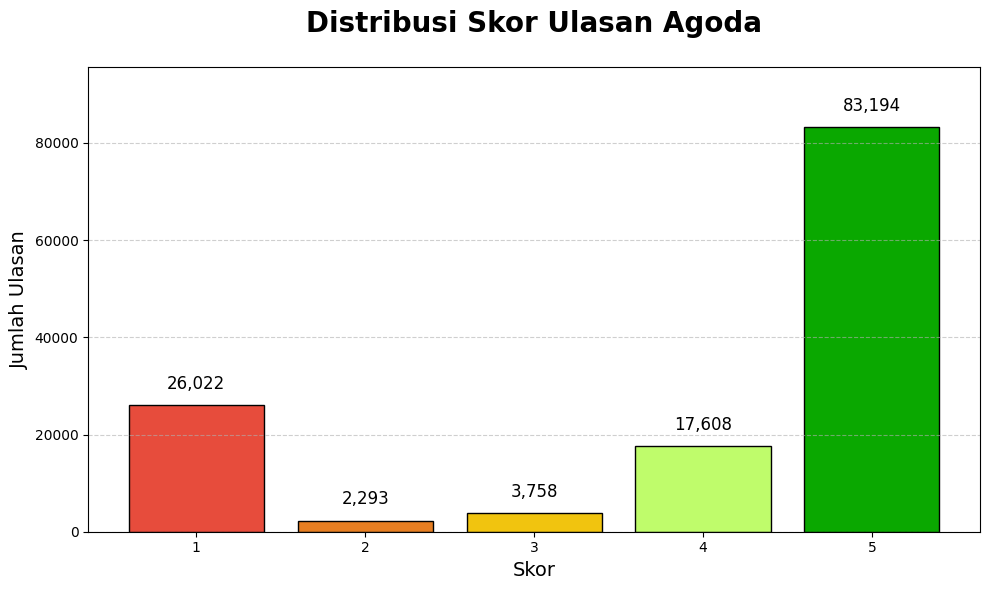

In [65]:
import matplotlib.pyplot as plt

# Hitung jumlah review berdasarkan skor dari df_agodarev
df_count = df_agodarev['score'].value_counts().sort_index()

# Mapping warna
score_colors = {
    1: '#e74c3c',
    2: '#e67e22',
    3: '#f1c40f',
    4: '#bffc6b',
    5: '#0aa800',
}

colors = [score_colors[score] for score in df_count.index]

plt.figure(figsize=(10, 6))

# Plot bar
bars = plt.bar(df_count.index, df_count.values, color=colors, edgecolor='black', linewidth=1)

# Judul & label
plt.title('Distribusi Skor Ulasan Agoda', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Skor', fontsize=14)
plt.ylabel('Jumlah Ulasan', fontsize=14)

# Tambah ruang di atas
max_val = max(df_count.values)
plt.ylim(top=max_val * 1.15)

# Grid halus
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Tambah label nilai pada bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + max_val * 0.03,
        f"{height:,}",
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.tight_layout()
plt.show()

### **Analisis Distribusi Rating per Versi Aplikasi**

Tahap ini bertujuan untuk mengevaluasi **konsistensi kualitas aplikasi** pada berbagai iterasi pembaruan (*update*). Dengan mengelompokkan data berdasarkan atribut **`reviewCreatedVersion`**, penelitian ini memetakan **proporsi skor rating** yang diberikan pengguna pada setiap versi tertentu. Visualisasi menggunakan **diagram batang bertumpuk (*stacked bar chart*)** ini memungkinkan peneliti untuk mengidentifikasi apakah suatu versi aplikasi tertentu mengalami peningkatan kualitas atau justru mengalami penurunan performa (regresi) berdasarkan persepsi pengguna secara komparatif.

Untuk melacak dinamika performa aplikasi secara kronologis, dilakukan analisis proporsi rating pada 10 versi aplikasi dengan volume ulasan terbanyak. Data versi aplikasi tersebut terlebih dahulu diurutkan dari rilis terlama hingga terbaru menggunakan metode *semantic versioning*. Pendekatan ini bertujuan untuk memetakan rekam jejak evolusi kualitas aplikasi, guna mengidentifikasi apakah pembaruan yang dilakukan oleh pengembang secara konsisten meningkatkan kepuasan pengguna atau justru memicu regresi performa.

Berdasarkan hasil visualisasi, terlihat tren stabilitas yang **sangat baik pada rilis awal hingga menengah** (seperti pada kelompok versi 2.x, 3.x, hingga 5.x), di mana sentimen positif (skor 4 dan 5) mendominasi secara absolut. Namun, pada fase rilis yang lebih baru, terjadi pergeseran tren yang memprihatinkan. Dimulai dengan munculnya peningkatan ulasan negatif berskala kecil pada versi **7.48.0**, puncaknya **terjadi regresi kualitas yang sangat tajam pada versi 10.49.0 dan 11.49.0**. Lonjakan drastis pada persentase ulasan berskor 1 (satu bintang) pada rilis-rilis terbaru ini menjadi indikator kuat bahwa pembaruan mutakhir aplikasi membawa *bug* sistemik atau perubahan antarmuka yang berdampak fatal terhadap pengalaman pengguna. Temuan ini menyoroti bahwa **pembaruan versi secara berkesinambungan tidak selalu berbanding lurus dengan peningkatan kualitas layanan aplikasi**.

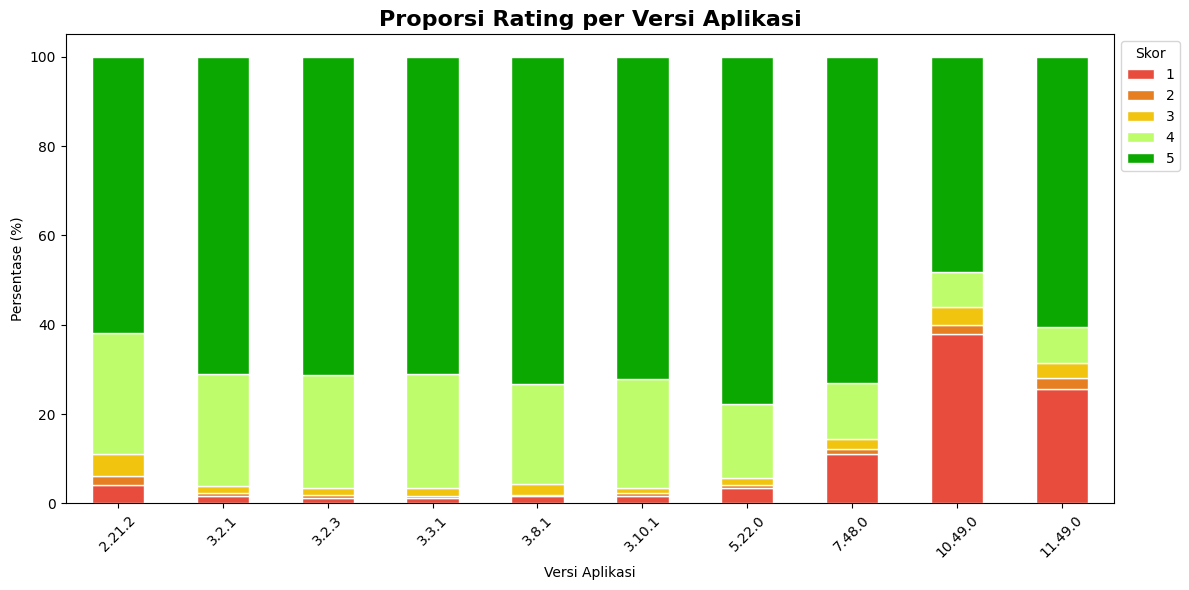

In [66]:
import matplotlib.pyplot as plt
from packaging import version

# 1. Ambil 10 versi dengan jumlah ulasan terbanyak (mengabaikan nilai kosong jika ada)
top_versions = df_agodarev['reviewCreatedVersion'].dropna().value_counts().nlargest(10).index.tolist()

# 2. Urutkan versi secara kronologis (dari terlama ke terbaru) menggunakan library 'packaging.version'
top_versions_sorted = sorted(top_versions, key=lambda x: version.parse(str(x)))

# 3. Filter data berdasarkan 10 versi tersebut
df_top_v = df_agodarev[df_agodarev['reviewCreatedVersion'].isin(top_versions_sorted)]

# 4. Hitung distribusi skor per versi
dist_v = df_top_v.groupby(['reviewCreatedVersion', 'score']).size().unstack(fill_value=0)

# 5. Pastikan indeks tabel mengikuti urutan versi yang sudah disortir
dist_v = dist_v.reindex(top_versions_sorted)

# 6. Ubah ke persentase
dist_v_pct = dist_v.div(dist_v.sum(axis=1), axis=0) * 100

# 7. Visualisasi Stacked Bar Chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#bffc6b', '#0aa800']
dist_v_pct.plot(kind='bar', stacked=True, figsize=(12, 6), color=colors, edgecolor='white')

plt.title("Proporsi Rating per Versi Aplikasi", fontsize=16, fontweight='bold')
plt.xlabel("Versi Aplikasi")
plt.ylabel("Persentase (%)")
plt.legend(title="Skor", bbox_to_anchor=(1, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Rangkuman Statistik**

In [67]:
df_agodarev.describe().loc[:, ['score', 'thumbsUpCount']]

,score,thumbsUpCount
count,132875.000000,132875.000000
mean,3.975797,1.227801
min,1.000000,0.000000
25%,4.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,0.000000
max,5.000000,3321.000000
std,1.576513,17.965249


### **Analisis Tren Frekuensi Ulasan Tahunan**

Untuk memahami dinamika pertumbuhan data dari waktu ke waktu, dilakukan **analisis tren tahunan** dengan mengelompokkan jumlah ulasan berdasarkan atribut waktu (**at**). Visualisasi menggunakan **diagram garis (*line chart*)** ini bertujuan untuk memetakan **fluktuasi volume ulasan** yang masuk ke aplikasi Agoda pada setiap periode tahun. Observasi terhadap tren ini sangat penting untuk mengidentifikasi pola pertumbuhan pengguna serta memastikan bahwa dataset mencakup rentang waktu yang representatif guna mendukung validitas temuan penelitian dalam konteks temporal.

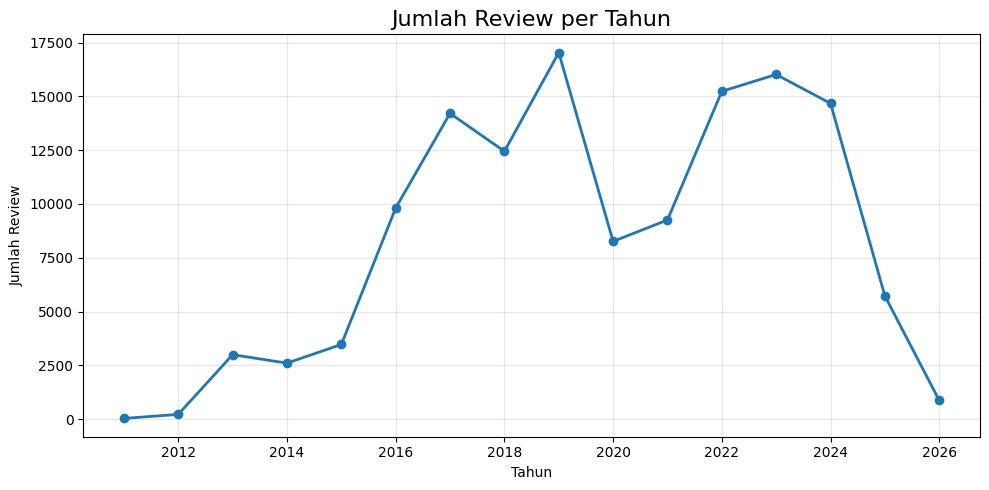

In [68]:
df_yearly = df_agodarev.groupby(df_agodarev['at'].dt.year).size()

plt.figure(figsize=(10,5))
plt.plot(df_yearly.index, df_yearly.values, marker='o', linewidth=2)

plt.title("Jumlah Review per Tahun", fontsize=16)
plt.xlabel("Tahun")
plt.ylabel("Jumlah Review")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

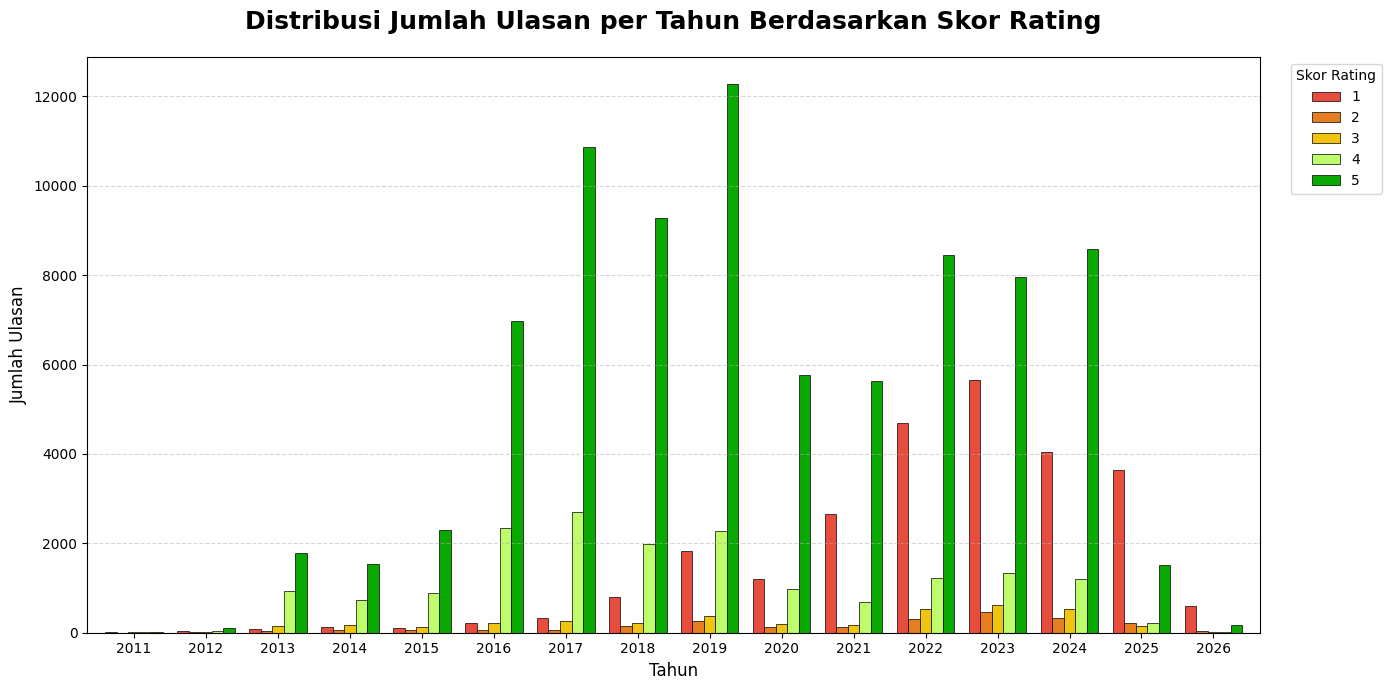

In [77]:
import matplotlib.pyplot as plt

# 1. Kelompokkan data berdasarkan Tahun dan Skor
df_yearly_score_count = df_agodarev.groupby([df_agodarev['at'].dt.year, 'score']).size().unstack(fill_value=0)

# 2. Mapping warna
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#bffc6b', '#0aa800']

# 3. Visualisasi dengan Grouped Bar Chart
df_yearly_score_count.plot(kind='bar', figsize=(14, 7), color=colors, edgecolor='black', linewidth=0.5, width=0.8)

plt.title("Distribusi Jumlah Ulasan per Tahun Berdasarkan Skor Rating", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Tahun", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)
plt.legend(title="Skor Rating", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Analisis Tren Rata-rata Skor Tahunan**

Tahap ini bertujuan untuk mengevaluasi **fluktuasi kualitas layanan** berdasarkan persepsi pengguna dari waktu ke waktu. Dengan menghitung **rata-rata skor ulasan per tahun**, penelitian ini dapat mengidentifikasi tren **tingkat kepuasan pengguna** secara kronologis. Visualisasi menggunakan **diagram garis** ini mempermudah pemantauan performa aplikasi Agoda dalam rentang waktu penelitian, serta memberikan gambaran apakah kualitas pengalaman pengguna cenderung stabil, meningkat, atau menurun setiap tahunnya.

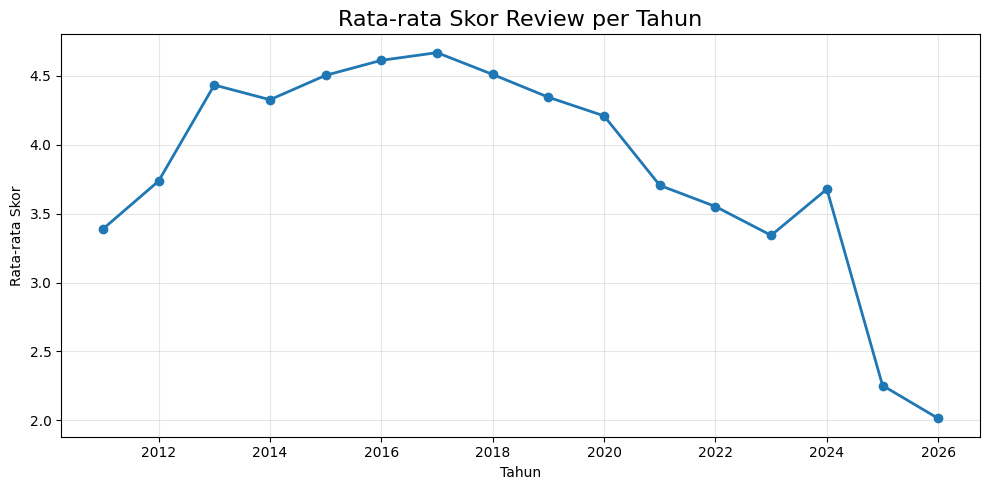

In [69]:
df_yearly_score = df_agodarev.groupby(df_agodarev['at'].dt.year)['score'].mean()

plt.figure(figsize=(10,5))
plt.plot(df_yearly_score.index, df_yearly_score.values, marker='o', linewidth=2)

plt.title("Rata-rata Skor Review per Tahun", fontsize=16)
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Skor")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Analisis Distribusi Panjang Ulasan**

Tahap ini dilakukan untuk memahami **karakteristik dimensi teks** melalui perhitungan jumlah karakter pada setiap ulasan. Menggunakan visualisasi **histogram**, penelitian ini memetakan **sebaran panjang ulasan** guna mengidentifikasi kecenderungan pengguna dalam memberikan umpan balik, apakah cenderung singkat atau deskriptif. Analisis ini sangat krusial untuk **mendeteksi keberadaan pencilan (*outliers*)** serta memberikan gambaran mengenai kepadatan informasi yang tersedia pada dataset sebelum diproses lebih lanjut pada tahap analisis sentimen.

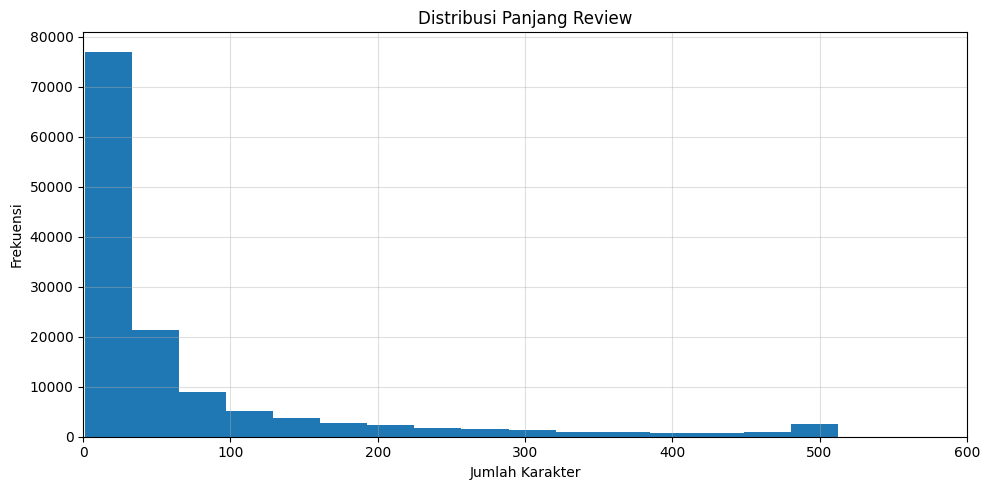

In [70]:
df_agodarev['text_length'] = df_agodarev['content'].astype(str).apply(len)
plt.figure(figsize=(10,5))
plt.hist(df_agodarev['text_length'], bins=50)
plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.xlim(0, 600)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### **Analisis Statistik Panjang Ulasan berdasarkan Skor**

Dilakukan **analisis statistik deskriptif** untuk menelaah hubungan antara **skor rating** dengan **panjang ulasan (jumlah karakter)**. Data dikelompokkan berdasarkan nilai skor untuk menghitung berbagai **metrik statistik** seperti jumlah ulasan, rata-rata, nilai tengah, dan nilai maksimum panjang teks pada setiap kategori. Tahap ini bertujuan untuk memberikan gambaran mendalam mengenai **pola perilaku pengguna** dalam memberikan deskripsi ulasan pada setiap tingkat kepuasan yang berbeda.

In [71]:
df_agodarev['text_length'] = df_agodarev['content'].astype(str).apply(len)
df_agodarev.groupby('score')['text_length'].agg(['count','mean','median','max'])

,count,mean,median,max
score,,,,
1,26022,199.332680,160.0,1453
2,2293,158.497165,110.0,1600
3,3758,80.114689,40.0,895
4,17608,37.549523,19.0,546
5,83194,30.429045,17.0,640


### **Analisis Frekuensi Kata (Word Frequency Analysis)**

Tahap ini bertujuan untuk mengidentifikasi **kata kunci dominan** atau tren istilah yang paling sering muncul dalam dataset ulasan. Melalui penggunaan **ekspresi reguler (*regular expression*)**, teks difilter untuk mengekstraksi kata dengan panjang minimal tiga karakter guna menghindari *noise* dari partikel kata yang tidak bermakna. Hasil perhitungan frekuensi dari **20 kata teratas** kemudian divisualisasikan dalam bentuk **diagram batang horizontal**, yang memungkinkan peneliti untuk memahami secara intuitif **konteks utama ulasan** pengguna sebelum data diproses lebih lanjut.

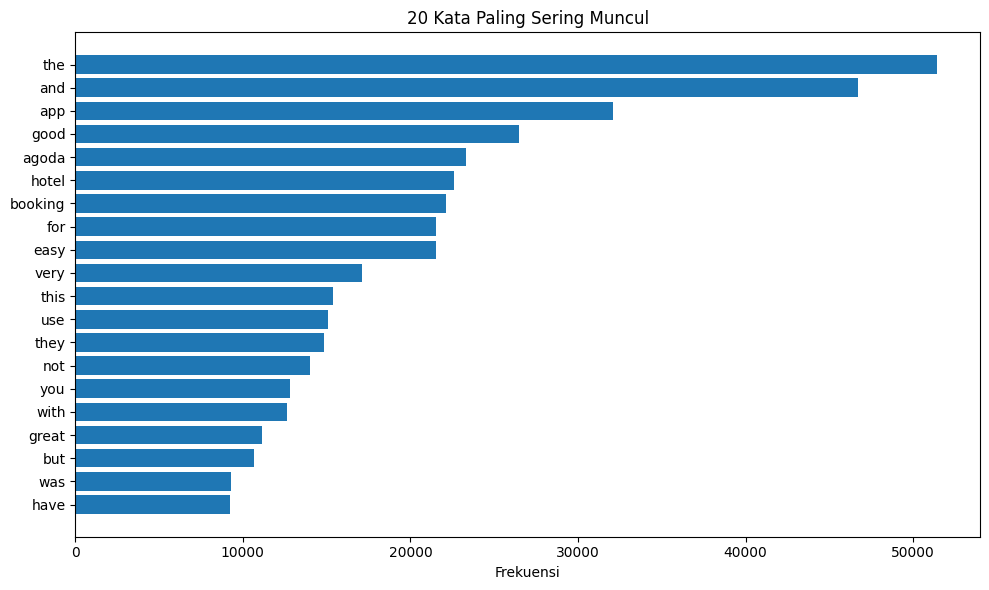

In [72]:
from collections import Counter
import re

all_text = " ".join(df_agodarev['content'].dropna()).lower()
words = re.findall(r'\b[a-zA-Z]{3,}\b', all_text)

word_counts = Counter(words).most_common(20)

labels, values = zip(*word_counts)

plt.figure(figsize=(10,6))
plt.barh(labels, values)
plt.title("20 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### **Analisis Responsivitas Pengembang (Reply Rate Analysis)**

Tahap ini dilakukan untuk mengukur tingkat interaksi pengembang aplikasi terhadap umpan balik pengguna. Dengan mengidentifikasi keberadaan konten pada atribut **`replyContent`**, dataset dikategorikan menjadi ulasan yang **mendapatkan balasan** dan yang **tidak dibalas**. Hasil kategori tersebut kemudian divisualisasikan dalam bentuk **diagram lingkaran (*pie chart*)** untuk menunjukkan **persentase responsivitas pengembang** secara proporsional. Analisis ini memberikan gambaran mengenai sejauh mana keterlibatan pihak pengembang dalam menanggapi ulasan serta menangani keluhan pengguna yang masuk melalui platform.

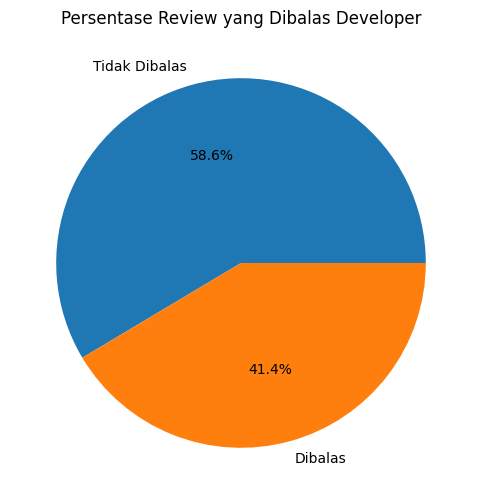

In [73]:
df_agodarev['is_replied'] = df_agodarev['replyContent'].notnull()

reply_counts = df_agodarev['is_replied'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(reply_counts, labels=["Tidak Dibalas", "Dibalas"], autopct="%1.1f%%")
plt.title("Persentase Review yang Dibalas Developer")
plt.show()

### **Analisis Kecepatan Respons Pengembang**

Tahap ini bertujuan untuk mengukur efisiensi pengembang dalam menanggapi ulasan pengguna dengan menghitung **durasi waktu respons (*response time*)**. Selisih waktu antara tanggal ulasan dikirim (**`at`**) dan tanggal balasan diberikan (**`repliedAt`**) dihitung dalam satuan hari. Selanjutnya, data tersebut dikategorikan ke dalam beberapa interval waktu menggunakan fungsi **`pd.cut`**, mulai dari kategori kurang dari satu hari hingga lebih dari tiga puluh hari. Analisis distribusi ini berfungsi untuk mengevaluasi **tingkat kesigapan pengembang** dalam menangani umpan balik, yang secara tidak langsung dapat memengaruhi persepsi dan kepuasan pengguna terhadap layanan aplikasi.

In [74]:
df_reply = df_agodarev[df_agodarev['replyContent'].notna()].copy()
df_reply['at'] = pd.to_datetime(df_reply['at'])
df_reply['repliedAt'] = pd.to_datetime(df_reply['repliedAt'])
df_reply['response_days'] = (df_reply['repliedAt'] - df_reply['at']).dt.days

In [75]:
df_reply['response_category'] = pd.cut(
    df_reply['response_days'],
    bins=[0,1,3,7,14,30,365],
    labels=["<1 hari","1–3 hari","3–7 hari","7–14 hari","14–30 hari",">30 hari"]
)

df_reply['response_category'].value_counts().sort_index()

,count
response_category,
<1 hari,1663
1–3 hari,784
3–7 hari,249
7–14 hari,137
14–30 hari,96
>30 hari,234


### **Visualisasi Awan Kata (Word Cloud) Berdasarkan Representasi Data Mentah**

Sebagai bagian dari analisis data eksploratif (EDA), dilakukan pemetaan representasi leksikal menggunakan **awan kata (*word cloud*)** secara langsung pada dataset mentah (*raw data*). Pendekatan ini bertujuan untuk menangkap bentuk ulasan pengguna secara natural dan apa adanya sebelum dilakukan intervensi pra-pemrosesan teks. Dataset diklasifikasikan ke dalam tiga kelas polaritas sentimen berdasarkan skor ulasan: **Positif (skor 4-5)**, **Netral (skor 3)**, dan **Negatif (skor 1-2)**. Visualisasi dirancang dengan memperbesar ukuran tipografi (*font size*) secara proporsional terhadap frekuensi kemunculan kata pada masing-masing kelas sentimen.

Melalui visualisasi data mentah ini, dapat diobservasi kata-kata yang menjadi inti opini pengguna pada kondisi aktual. Pada awan kata kelas positif, tervisualisasi aspek layanan yang paling menonjol dan memuaskan (*strengths*), sedangkan pada kelas negatif, terakumulasi kumpulan kosakata natural yang merepresentasikan keluhan langsung terhadap malfungsi atau defisiensi aplikasi (*pain points*). Analisis deskriptif visual ini sangat penting sebagai titik tolak observasi untuk memahami konteks permasalahan secara utuh, yang nantinya akan divalidasi dan dipertajam setelah data melalui tahapan pembersihan dan ekstraksi fitur formal.

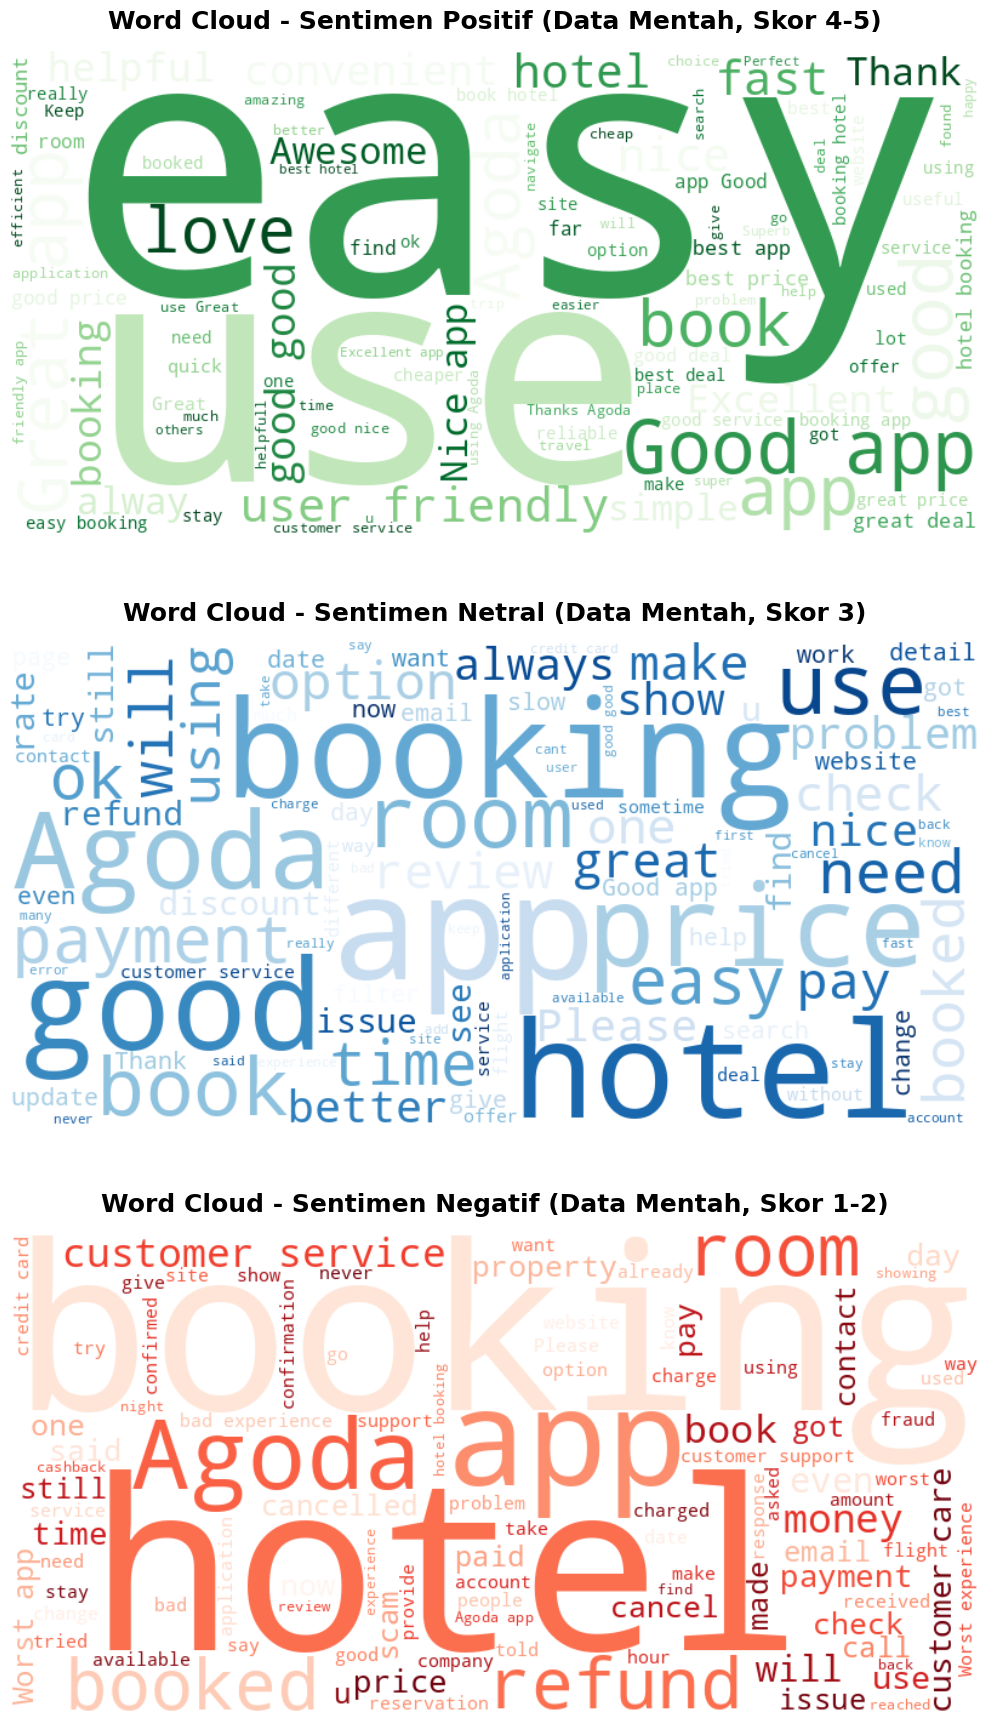

In [78]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Kategorisasi sentimen berdasarkan skor
def categorize_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df_agodarev['sentiment_category'] = df_agodarev['score'].apply(categorize_sentiment)

# 2. Menggabungkan teks mentah (kolom 'content') untuk masing-masing kategori
# Menggunakan dropna() untuk menghindari error jika ada ulasan yang kosong, lalu diubah ke string
text_positif = " ".join(df_agodarev[df_agodarev['sentiment_category'] == 'Positif']['content'].dropna().astype(str))
text_netral = " ".join(df_agodarev[df_agodarev['sentiment_category'] == 'Netral']['content'].dropna().astype(str))
text_negatif = " ".join(df_agodarev[df_agodarev['sentiment_category'] == 'Negatif']['content'].dropna().astype(str))

# 3. Inisialisasi konfigurasi Word Cloud
# Secara default, pustaka WordCloud sudah membuang kata hubung (stopwords) dasar bahasa Inggris
wc_positif = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(text_positif)
wc_netral = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=100).generate(text_netral)
wc_negatif = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif)

# 4. Visualisasi dalam bentuk subplot (3 baris, 1 kolom)
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

axes[0].imshow(wc_positif, interpolation='bilinear')
axes[0].set_title('Word Cloud - Sentimen Positif (Data Mentah, Skor 4-5)', fontsize=18, fontweight='bold', pad=15)
axes[0].axis('off')

axes[1].imshow(wc_netral, interpolation='bilinear')
axes[1].set_title('Word Cloud - Sentimen Netral (Data Mentah, Skor 3)', fontsize=18, fontweight='bold', pad=15)
axes[1].axis('off')

axes[2].imshow(wc_negatif, interpolation='bilinear')
axes[2].set_title('Word Cloud - Sentimen Negatif (Data Mentah, Skor 1-2)', fontsize=18, fontweight='bold', pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### **Visualisasi Awan Kata (Word Cloud) Pasca Pra-pemrosesan Data**

Setelah dataset ulasan Agoda melewati seluruh rangkaian pra-pemrosesan data (*data preprocessing*) seperti yang saya lakukan pada [Week 3 disini](https://github.com/celiineauriiel/PBA_Agoda-SentimentAnalysis/blob/main/Week%203/4_Agoda_Preprocessing.ipynb) —meliputi penyaringan bahasa, normalisasi, lematisasi, hingga penghapusan kata langka dan tanda baca—dilakukan kembali visualisasi **awan kata (*word cloud*)** pada korpus teks yang telah bersih (*cleaned data*). Visualisasi ini diklasifikasikan ke dalam tiga polaritas sentimen berdasarkan skor rating: **Positif (skor 4-5)**, **Netral (skor 3)**, dan **Negatif (skor 1-2)**.

Berbeda dengan representasi pada data mentah, visualisasi pasca pra-pemrosesan ini memberikan gambaran fitur linguistik yang jauh lebih murni, padat, dan representatif. Kata-kata tidak bermakna (*stopwords*), variasi infleksi, dan kata-kata pencilan telah dieleminasi, sehingga *word cloud* yang dihasilkan secara akurat menonjolkan term-term esensial yang menjadi pembentuk utama dari sentimen pengguna. Pada kelas sentimen positif, tervisualisasi lema-lema kunci yang mendeskripsikan kepuasan spesifik terhadap fitur layanan aplikasi. Sebaliknya, pada kelas sentimen negatif, terisolasi istilah-istilah murni yang secara langsung merujuk pada kendala operasional atau kelemahan aplikasi. Hasil visualisasi ini mengonfirmasi bahwa dataset telah memiliki konsistensi semantik yang tinggi dan siap untuk dilanjutkan ke tahap ekstraksi fitur pada analisis selanjutnya.

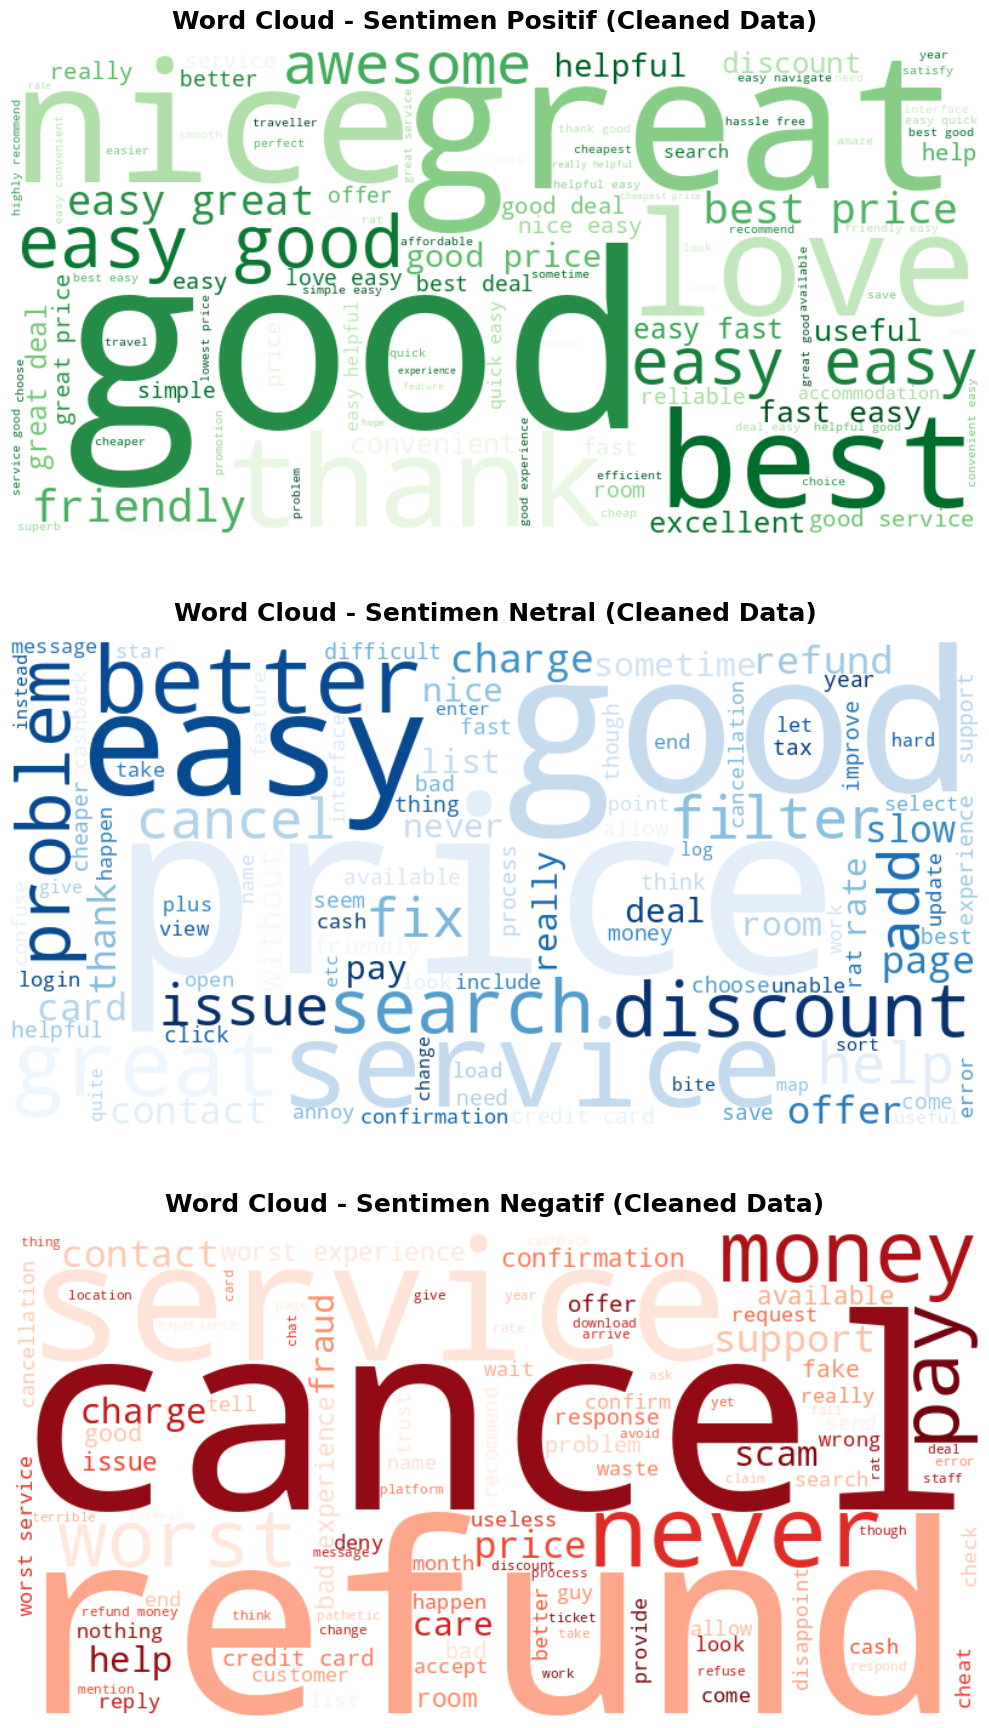

In [80]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Memuat dataset yang sudah dibersihkan
df_cleaned = pd.read_csv('/content/drive/My Drive/PBA/cleandata.csv')

# 2. Kategorisasi sentimen berdasarkan skor
def categorize_sentiment(score):
    if score <= 2:
        return 'Negatif'
    elif score == 3:
        return 'Netral'
    else:
        return 'Positif'

df_cleaned['sentiment_category'] = df_cleaned['score'].apply(categorize_sentiment)

# 3. Menggabungkan teks bersih untuk masing-masing kategori
# Menggunakan kolom 'content_cleaned'
col_name = 'content_cleaned'

text_positif = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Positif'][col_name].dropna().astype(str))
text_netral = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Netral'][col_name].dropna().astype(str))
text_negatif = " ".join(df_cleaned[df_cleaned['sentiment_category'] == 'Negatif'][col_name].dropna().astype(str))

# Membersihkan karakter sisa dari format CSV
for char in ["'", '"', "[", "]", ","]:
    text_positif = text_positif.replace(char, "")
    text_netral = text_netral.replace(char, "")
    text_negatif = text_negatif.replace(char, "")

# 4. Inisialisasi Word Cloud
wc_positif = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(text_positif)
wc_netral = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=100).generate(text_netral)
wc_negatif = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(text_negatif)

# 5. Visualisasi Subplot
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

axes[0].imshow(wc_positif, interpolation='bilinear')
axes[0].set_title('Word Cloud - Sentimen Positif (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[0].axis('off')

axes[1].imshow(wc_netral, interpolation='bilinear')
axes[1].set_title('Word Cloud - Sentimen Netral (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[1].axis('off')

axes[2].imshow(wc_negatif, interpolation='bilinear')
axes[2].set_title('Word Cloud - Sentimen Negatif (Cleaned Data)', fontsize=18, fontweight='bold', pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()